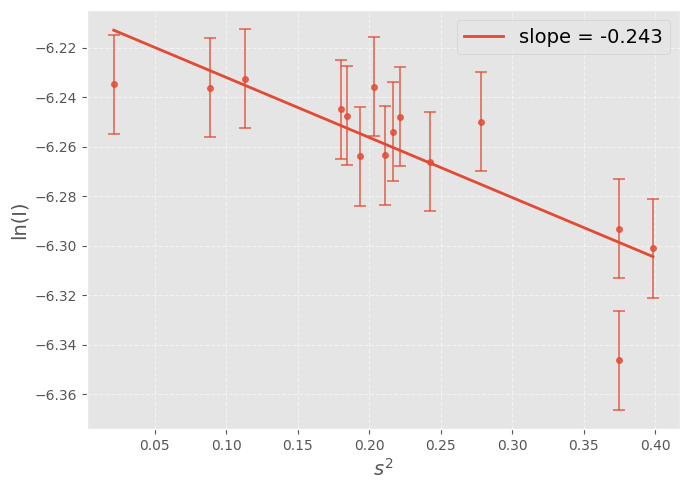

First orientation slope = -0.2426


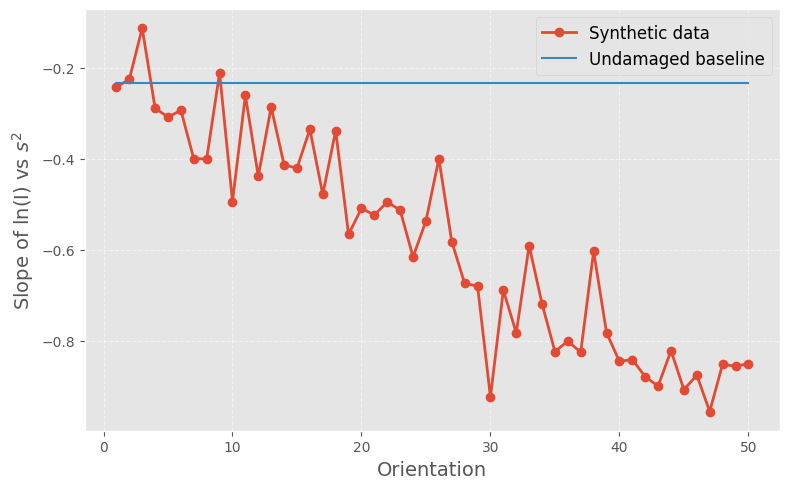

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")   # ggplot style colours

# ============================================================
# 1. LOAD + PREPARE DATA
# ============================================================

df_raw = pd.read_csv("/content/synthetic_damage_clean.csv")

# Split hkl into integer columns
df_raw[['h','k','l']] = df_raw['hkl'].str.split(expand=True).astype(int)

# Rename columns for consistency
df_raw = df_raw.rename(columns={
    'G-vector Length': 'g_mag',
    'orientation': '_refln_zone_axis_id',
    'Intensity': 'norm_intensity'
})

# ============================================================
# 1b. ADD NOISE TO ln(I)
# ============================================================

lnI = np.log(df_raw['norm_intensity'].values)

lnI_sigma = 0.02   # <-- ERROR LEVEL YOU REQUESTED
lnI_noisy = lnI + np.random.normal(0, lnI_sigma, size=len(lnI))

df_raw['norm_intensity'] = np.exp(lnI_noisy)


# ============================================================
# 2. SIGMA FILTERS + REMOVE DUPLICATES
# ============================================================

df3 = df_raw[df_raw['_refln_intensity_meas'] >= 3 * df_raw['_refln_intensity_sigma']].copy()
df3_unique = df3.drop_duplicates(subset=['h','k','l'], keep='first')


# ============================================================
# 3. FIRST ORIENTATION WILSON PLOT (with error bars)
# ============================================================

def wilson_first_orientation(df_in, title_prefix="", min_points=10):

    g_mag = df_in["g_mag"].astype(float).values
    Ivals = df_in["norm_intensity"].astype(float).values
    ori   = df_in["_refln_zone_axis_id"].astype(int).values

    s2 = (g_mag / 2.0)**2

    good = Ivals > 0
    s2 = s2[good]
    Ivals = Ivals[good]
    ori = ori[good]
    lnI = np.log(Ivals)

    # FIRST ORIENTATION ONLY
    first_ori = np.min(ori)
    mask = (ori == first_ori)
    s2_sub = s2[mask]
    lnI_sub = lnI[mask]

    if len(s2_sub) < min_points:
        print("Not enough reflections.")
        return None

    # Sort for clean plotting
    idx = np.argsort(s2_sub)
    s2_sorted = s2_sub[idx]
    lnI_sorted = lnI_sub[idx]

    # Fit slope
    slope, intercept = np.polyfit(s2_sorted, lnI_sorted, 1)

    # ============================================================
    # PLOT ERROR BARS + RAW POINTS + FITTED LINE
    # ============================================================

    plt.figure(figsize=(7,5))

    # Error bars (uniform lnI error = 0.02)

    plt.errorbar(
    s2_sorted,
    lnI_sorted,
    yerr=lnI_sigma,
    fmt='o',
    markersize=4,
    color="C0",
    alpha=0.8,
    capsize=4,          # length of whisker cap
    elinewidth=1.2,     # thickness of error bar line
    capthick=1.2        # thickness of the whisker cap
)


    # Best‑fit line
    xf = np.linspace(s2_sorted.min(), s2_sorted.max(), 300)
    plt.plot(xf, slope*xf + intercept, color="C0", lw=2,
             label=f"slope = {slope:.3f}")

    plt.xlabel("$s^2$", fontsize=14)
    plt.ylabel("ln(I)", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{title_prefix}wilson_first_orientation.pdf", dpi=600)
    plt.show()

    print(f"First orientation slope = {slope:.4f}")
    return slope


# Run first orientation plot
wilson_first_orientation(df3_unique, title_prefix="Synthetic Damage (3σ)")


# ============================================================
# 4. COMPUTE SLOPES FOR ALL ORIENTATIONS
# ============================================================

def compute_slopes_all_orientations(df_in, min_points=10):

    g_mag = df_in["g_mag"].astype(float).values
    Ivals = df_in["norm_intensity"].astype(float).values
    ori   = df_in["_refln_zone_axis_id"].astype(int).values

    s2 = (g_mag / 2.0)**2

    good = (Ivals > 0)
    s2 = s2[good]
    lnI = np.log(Ivals[good])
    ori = ori[good]

    max_ori = int(ori.max())
    slopes = []
    oris   = []

    for o in range(1, max_ori + 1):
        mask = ori == o
        s2_sub = s2[mask]
        lnI_sub = lnI[mask]

        if len(s2_sub) < min_points:
            slopes.append(np.nan)
            oris.append(o)
            continue

        idx = np.argsort(s2_sub)
        slope, intercept = np.polyfit(s2_sub[idx], lnI_sub[idx], 1)

        slopes.append(slope)
        oris.append(o)

    return np.array(oris), np.array(slopes)

oris, slopes = compute_slopes_all_orientations(df3_unique)


# ============================================================
# 5. FINAL PLOT: SLOPE VS ORIENTATION
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(oris, slopes, "o-", color="C0", lw=2, markersize=6, label='Synthetic data')
plt.plot(oris, np.full_like(slopes, (slopes[0]+slopes[1])/2), color="C1", label='Undamaged baseline')
plt.xlabel("Orientation", size=14)
plt.ylabel("Slope of ln(I) vs $s^2$", size=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("synthetic_damage_slope_vs_orientation.pdf", dpi=600)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# SYNTHETIC DATASET WITH GUARANTEED MONOTONICALLY DECREASING SLOPES
# ============================================================

n_orientations = 50       # 50 orientations
rows_per_ori   = 15       # 15 reflections each

# Slope behaviour: ln(I) = -B(ori) * s^2
B0 = 0.20                 # initial slope magnitude
B_increase = 0.015        # slope change per orientation

noise_intensity = 0.02    # VERY small noise (clean)
noise_sigma = 0.000002

rng = np.random.default_rng(42)

data = {
    "hkl": [],
    "_refln_intensity_meas": [],
    "_refln_intensity_sigma": [],
    "G-vector Length": [],
    "Intensity": [],
    "orientation": []
}

for ori in range(1, n_orientations + 1):

    # Monotonically increasing B (hence more negative slope)
    B = B0 + B_increase * ori

    for _ in range(rows_per_ori):

        # Generate random h,k,l
        h = rng.integers(-7, 8)
        k = rng.integers(-7, 8)
        l = rng.integers(-7, 8)
        hkl_string = f"{h} {k} {l}"

        # Compute realistic g-vector magnitude
        g = 0.12 * np.sqrt(h*h + k*k + l*l) + 0.08
        g += 0.01 * rng.normal()
        g = abs(g)

        s2 = (g/2)**2

        # Ideal intensity model (perfect Wilson slope)
        I_true = np.exp(-B * s2)

        # Add very small noise (tiny multiplicative)
        I_meas = I_true * (1 + noise_intensity * rng.normal())
        I_meas = max(I_meas, I_true * 0.9)

        # Sigma also slightly increases with orientation
        sigma = 0.00010 + noise_sigma * ori

        # "Intensity" column like PETS (tiny corrected intensity)
        I_clean = I_meas * 0.002 + 1e-6

        # Store
        data["hkl"].append(hkl_string)
        data["_refln_intensity_meas"].append(I_meas)
        data["_refln_intensity_sigma"].append(sigma)
        data["G-vector Length"].append(g)
        data["Intensity"].append(I_clean)
        data["orientation"].append(ori)

df = pd.DataFrame(data)
df.to_csv("synthetic_damage_clean.csv", index=False)

df.head()

,hkl,_refln_intensity_meas,_refln_intensity_sigma,G-vector Length,Intensity,orientation
0,-6 4 2,0.966991,0.000102,0.985502,0.001935,1
1,-1 -4 -6,0.955998,0.000102,0.940591,0.001913,1
2,3 4 0,0.993224,0.000102,0.671470,0.001987,1
3,-6 -5 6,0.938586,0.000102,1.262523,0.001878,1
4,1 -1 -1,0.976352,0.000102,0.291534,0.001954,1


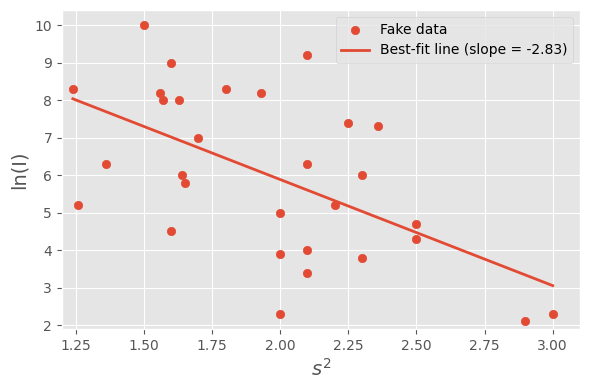

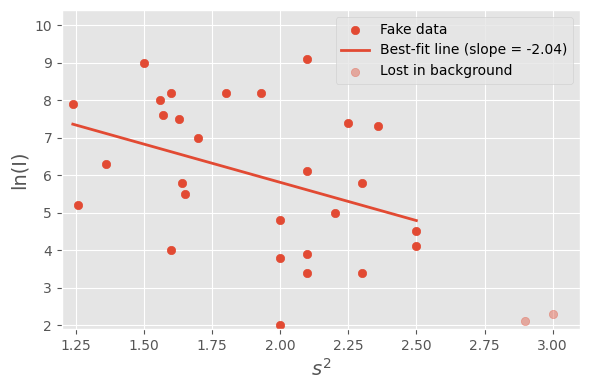

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")   # ggplot style colours

import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

lnI = [10, 9, 8, 8.3, 8.2, 6, 7, 8, 5, 6, 4, 5.2, 4.3, 5.8, 9.2, 6.3, 2.3, 4.5, 2.3, 4.7, 3.4, 3.8, 3.9, 2.1, 8.3, 8.2, 7.4, 7.3, 5.2, 6.3 ]
s2  = [1.5, 1.6, 1.63, 1.24, 1.56, 1.64, 1.7, 1.57, 2, 2.3, 2.1, 2.2, 2.5, 1.65, 2.1, 2.1, 2, 1.6, 3, 2.5, 2.1, 2.3, 2, 2.9, 1.8, 1.93, 2.25, 2.36, 1.26, 1.36]

# Convert to numpy arrays
s2 = np.array(s2)
lnI = np.array(lnI)

# Fit a line: ln(I) = m*s² + b
m, b = np.polyfit(s2, lnI, 1)

# Generate fitted line values
s2_fit = np.linspace(min(s2), max(s2), 200)
lnI_fit = m * s2_fit + b

# Plot scatter
plt.figure(figsize=(6,4))
plt.scatter(s2, lnI, color="C0", label="Fake data")

# Plot best‑fit line
plt.plot(s2_fit, lnI_fit, color="C0", linewidth=2,
         label=f"Best‑fit line (slope = {m:.2f})")

plt.xlabel("$s^2$", fontsize=14)
plt.ylabel("ln(I)", fontsize=14)
plt.xlim(1.2, 3.1)
plt.ylim(1.9, 10.4)
plt.grid(True)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("SyntheticaffectingB.pdf", dpi=600)
plt.show()


lnI = [9, 8.2, 7.5, 7.9, 8, 5.8, 7, 7.6, 4.8, 5.8, 3.9, 5, 4.1, 5.5, 9.1, 6.1, 2, 4, 4.5, 3.4, 3.4, 3.8, 8.2, 8.2, 7.4, 7.3, 5.2, 6.3]
s2  = [1.5, 1.6, 1.63, 1.24, 1.56, 1.64, 1.7, 1.57, 2, 2.3, 2.1, 2.2, 2.5, 1.65, 2.1, 2.1, 2, 1.6, 2.5, 2.1, 2.3, 2, 1.8, 1.93, 2.25, 2.36, 1.26, 1.36]

# Convert to numpy arrays
s2 = np.array(s2)
lnI = np.array(lnI)

# Fit a line: ln(I) = m*s² + b
m, b = np.polyfit(s2, lnI, 1)

# Generate fitted line values
s2_fit = np.linspace(min(s2), max(s2), 200)
lnI_fit = m * s2_fit + b

# Plot scatter
plt.figure(figsize=(6,4))
plt.scatter(s2, lnI, color="C0", label="Fake data")

# Plot best‑fit line
plt.plot(s2_fit, lnI_fit, color="C0", linewidth=2,
         label=f"Best‑fit line (slope = {m:.2f})")
lostI = [2.1, 2.3 ]
losts2 = [2.9, 3]
plt.scatter(losts2, lostI, color="C0", alpha=0.4, label="Lost in background")
plt.xlabel("$s^2$", fontsize=14)
plt.ylabel("ln(I)", fontsize=14)
plt.xlim(1.2, 3.1)
plt.ylim(1.9, 10.4)
plt.grid(True)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("syntheticlostpeaksaffectingB.pdf", dpi=600)
plt.show()